In [49]:
import xarray as xr
import pandas as pd
import numpy as np
import cv2
import os

os.chdir('../..')

from utils import noise_at_level, crop_centered_window
from utils import plot_perturbation

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load Precipitation Data

In [29]:
# ground truth / reference
era5_ds = xr.open_zarr('gs://weatherbench2/datasets/era5/1959-2022-6h-1440x721.zarr', consolidated=True, decode_timedelta=True)
hres_ds = xr.open_zarr('gs://weatherbench2/datasets/hres/2016-2022-0012-1440x721.zarr', consolidated=True, decode_timedelta=True)

In [30]:
ref_day_reanalysis = '2016-01-02T06:00:000000000'
ref_day_forecasts = '2016-01-01T00:00:000000000'
lead_time = '1 days 06:00:00'

reanalysis_field = era5_ds.sel(time=ref_day_reanalysis, method='nearest').sortby('latitude').total_precipitation_6hr
forecast_field = hres_ds.sel(time=ref_day_forecasts, prediction_timedelta=lead_time).total_precipitation_6hr

## Convert precipition from meters to millimeters

In [31]:
reanalysis_field = reanalysis_field * 1000.0
forecast_field = forecast_field * 1000.0

# 0. Scores DataFrame

In [32]:
scores = pd.DataFrame(columns=['perturbation_type', 
                               'perturbation_params', 
                               'rmse',
                               'nrmse', 
                               'dssim', 
                               'haar_psi', 
                               'wavesim',
                               'wavesim_components',
                               ]).astype({
                                        'perturbation_type': 'str', 
                                        'perturbation_params': 'str',
                                        'rmse': np.float32,
                                        'nrmse': np.float32,
                                        'dssim': np.float32,
                                        'haar_psi': np.float32,
                                        'wavesim': np.float32,
                                        'wavesim_components': 'str',
                                        })

spatial_perturbations = {}

# 1. Spatial perturbations

## Cropping across a region in Europe

In [33]:
# centroid coordinates in Europe
center_lon = 10.0
center_lat = 49.75
patch_size = 256
shift_lon_deg = 0.0 # we don't shift here; it's the reference map
shift_lat_deg = 0.0 # we don't shift here; it's the reference map
reference = crop_centered_window(reanalysis_field, 
                                 center_lon = center_lon, 
                                 center_lat = center_lat, 
                                 size_lon = patch_size, 
                                 size_lat = patch_size, 
                                 shift_lon_deg = shift_lon_deg, 
                                 shift_lat_deg = shift_lat_deg)

## Perturbation #1 : spatial shift

### Case 1 : -1 deg longitudes

In [34]:
shift_lon_deg = -1.0
shift_lat_deg = 0.0
shifted_case_1 = crop_centered_window(reanalysis_field, 
                                      center_lon = center_lon, 
                                      center_lat = center_lat, 
                                      size_lon = patch_size,
                                      size_lat = patch_size,
                                      shift_lon_deg = shift_lon_deg,
                                      shift_lat_deg = shift_lat_deg)

params = {'shift_lon_deg' : shift_lon_deg, 'shift_lat_deg' : shift_lat_deg}
spatial_perturbations.update({'shifted_case_1' : {'perturbation_params' : params, 'values' : shifted_case_1.values}})

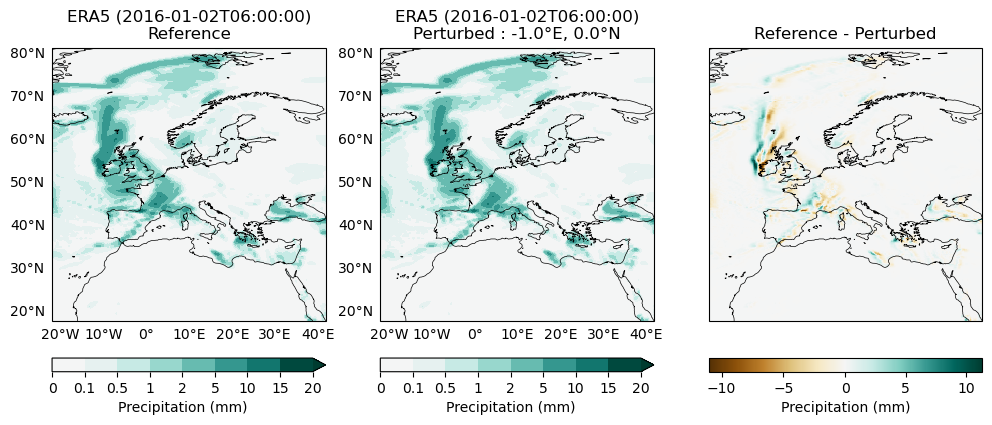

In [35]:
reference_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nReference'
perturbed_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nPerturbed : {shift_lon_deg}°E, {shift_lat_deg}°N'
cbar_label = 'Precipitation (mm)'
reference_coords = (reference.longitude, reference.latitude)
perturbed_coords = (shifted_case_1.longitude, shifted_case_1.latitude)
plot_perturbation(reference=reference.values, perturbed=shifted_case_1.values, reference_coords=reference_coords, perturbed_coords=perturbed_coords, reference_label=reference_label, perturbed_label=perturbed_label, cbar_label=cbar_label)

### Case 2 : -2 deg longitudes, 0 deg latitude

In [36]:
shift_lon_deg = -2.0
shift_lat_deg = 0.0
shifted_case_2 = crop_centered_window(reanalysis_field, 
                                      center_lon = center_lon, 
                                      center_lat = center_lat, 
                                      size_lon = patch_size,
                                      size_lat = patch_size,
                                      shift_lon_deg = shift_lon_deg,
                                      shift_lat_deg = shift_lat_deg)

params = {'shift_lon_deg' : shift_lon_deg, 'shift_lat_deg' : shift_lat_deg}
spatial_perturbations.update({'shifted_case_2' : {'perturbation_params' : params, 'values' : shifted_case_2.values}})

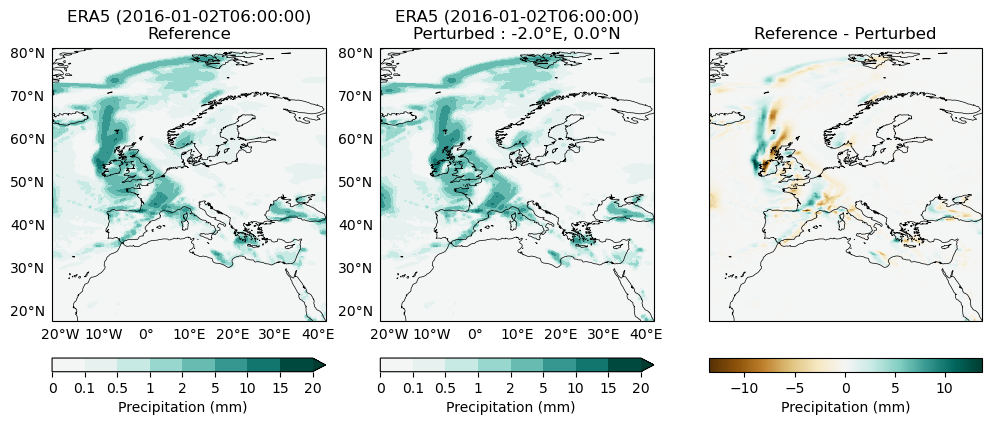

In [37]:
reference_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nReference'
perturbed_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nPerturbed : {shift_lon_deg}°E, {shift_lat_deg}°N'
cbar_label = 'Precipitation (mm)'
reference_coords = (reference.longitude, reference.latitude)
perturbed_coords = (shifted_case_2.longitude, shifted_case_2.latitude)
plot_perturbation(reference=reference.values, perturbed=shifted_case_2.values, reference_coords=reference_coords, perturbed_coords=perturbed_coords, reference_label=reference_label, perturbed_label=perturbed_label, cbar_label=cbar_label)

### Case 3 : -10 deg longitudes

In [38]:
shift_lon_deg = -10.0
shift_lat_deg = 0.0
shifted_case_3 = crop_centered_window(reanalysis_field, 
                                      center_lon = center_lon, 
                                      center_lat = center_lat, 
                                      size_lon = patch_size,
                                      size_lat = patch_size,
                                      shift_lon_deg = shift_lon_deg,
                                      shift_lat_deg = shift_lat_deg)

params = {'shift_lon_deg' : shift_lon_deg, 'shift_lat_deg' : shift_lat_deg}
spatial_perturbations.update({'shifted_case_4' : {'perturbation_params' : params, 'values' : shifted_case_4.values}})

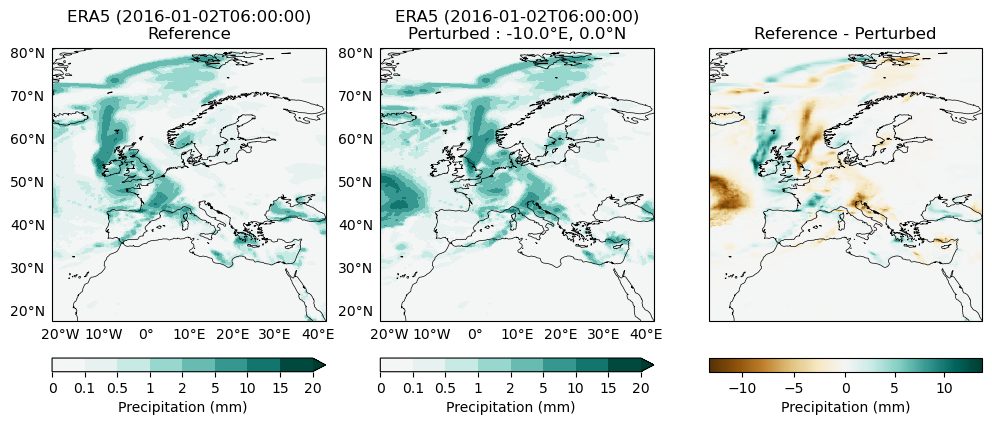

In [39]:
reference_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nReference'
perturbed_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nPerturbed : {shift_lon_deg}°E, {shift_lat_deg}°N'
cbar_label = 'Precipitation (mm)'
reference_coords = (reference.longitude, reference.latitude)
perturbed_coords = (shifted_case_3.longitude, shifted_case_3.latitude)
plot_perturbation(reference=reference.values, perturbed=shifted_case_3.values, reference_coords=reference_coords, perturbed_coords=perturbed_coords, reference_label=reference_label, perturbed_label=perturbed_label, cbar_label=cbar_label)

### Case 4 : -10 deg longitudes, -10 deg latitude

In [40]:
shift_lon_deg = -10.0
shift_lat_deg = -10.0
shifted_case_4 = crop_centered_window(reanalysis_field, 
                                      center_lon = center_lon, 
                                      center_lat = center_lat, 
                                      size_lon = patch_size,
                                      size_lat = patch_size,
                                      shift_lon_deg = shift_lon_deg,
                                      shift_lat_deg = shift_lat_deg)

params = {'shift_lon_deg' : shift_lon_deg, 'shift_lat_deg' : shift_lat_deg}
spatial_perturbations.update({'shifted_case_4' : {'perturbation_params' : params, 'values' : shifted_case_4.values}})

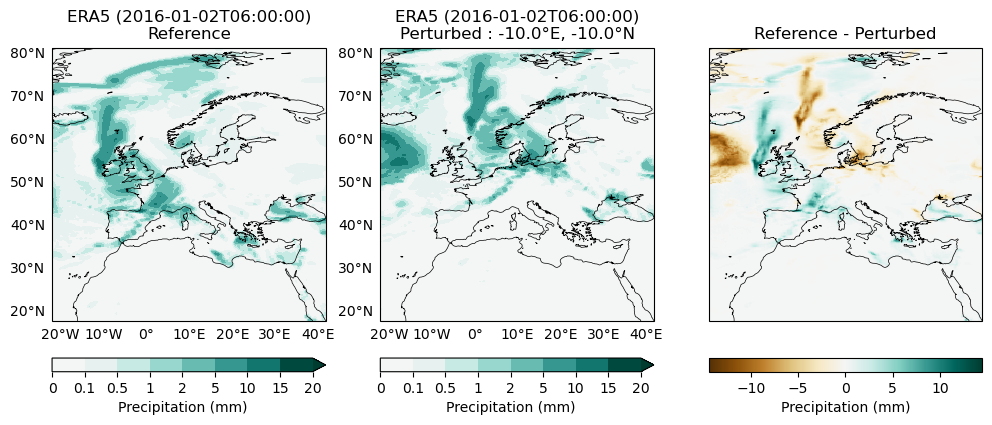

In [41]:
reference_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nReference'
perturbed_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nPerturbed : {shift_lon_deg}°E, {shift_lat_deg}°N'
cbar_label = 'Precipitation (mm)'
reference_coords = (reference.longitude, reference.latitude)
perturbed_coords = (shifted_case_4.longitude, shifted_case_4.latitude)
plot_perturbation(reference=reference.values, perturbed=shifted_case_4.values, reference_coords=reference_coords, perturbed_coords=perturbed_coords, reference_label=reference_label, perturbed_label=perturbed_label, cbar_label=cbar_label)

In [42]:
spatial_perturbations.keys()

dict_keys(['shifted_case_1', 'shifted_case_2', 'shifted_case_4'])

# Perturbation #2 : flip

### Case 1 : Horizontal flip

In [43]:
flip_case_1 = np.fliplr(reference.copy().values)
params = {'flip' : 'horizontal'}
spatial_perturbations.update({'flip_case_1' : {'perturbation_params' : params, 'values' : flip_case_1}})

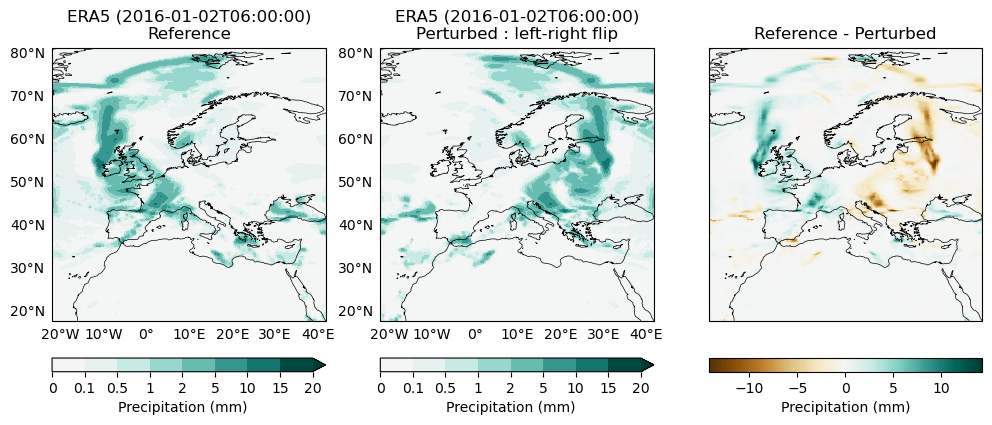

In [44]:
reference_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nReference'
perturbed_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nPerturbed : left-right flip'
cbar_label = 'Precipitation (mm)'
reference_coords = (reference.longitude, reference.latitude)
perturbed_coords = (reference.longitude, reference.latitude)
plot_perturbation(reference=reference.values, perturbed=flip_case_1, reference_coords=reference_coords, perturbed_coords=perturbed_coords, reference_label=reference_label, perturbed_label=perturbed_label, cbar_label=cbar_label)

### Case 2 : Vertical flip

In [45]:
flip_case_2 = np.flipud(reference.copy().values)
params = {'flip' : 'vertical'}
spatial_perturbations.update({'flip_case_2' : {'perturbation_params' : params, 'values' : flip_case_2}})

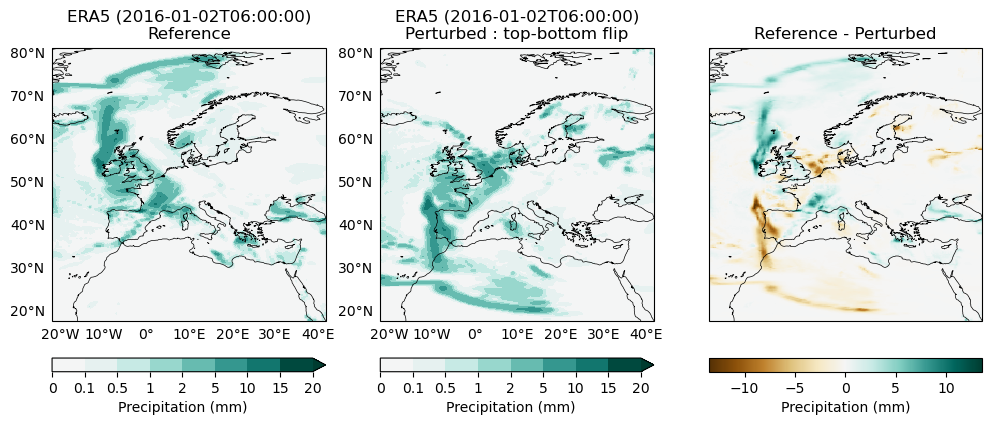

In [46]:
reference_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nReference'
perturbed_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nPerturbed : top-bottom flip'
cbar_label = 'Precipitation (mm)'
reference_coords = (reference.longitude, reference.latitude)
perturbed_coords = (reference.longitude, reference.latitude)
plot_perturbation(reference=reference.values, perturbed=flip_case_2, reference_coords=reference_coords, perturbed_coords=perturbed_coords, reference_label=reference_label, perturbed_label=perturbed_label, cbar_label=cbar_label)

### Case 3 : diagonal flip

In [47]:
flip_case_3 = reference.copy().values.T
params = {'flip' : 'diagonal'}
spatial_perturbations.update({'flip_case_3' : {'perturbation_params' : params, 'values' : flip_case_3}})

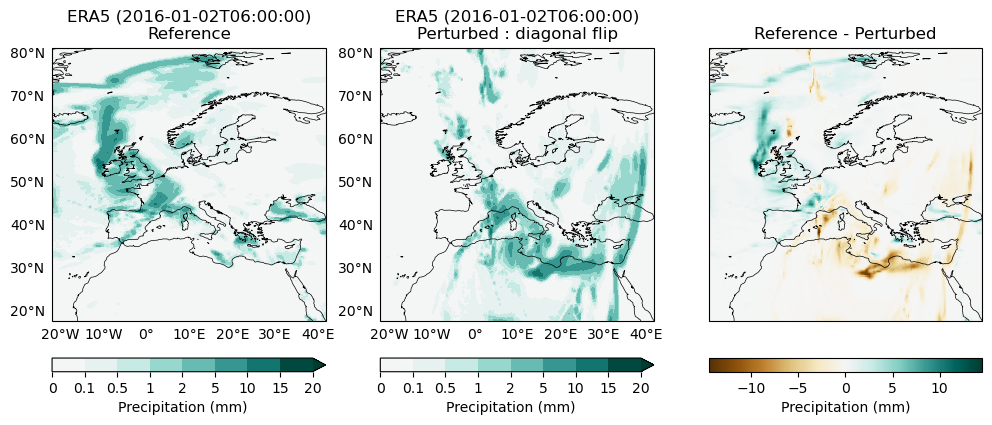

In [48]:
reference_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nReference'
perturbed_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nPerturbed : diagonal flip'
cbar_label = 'Precipitation (mm)'
reference_coords = (reference.longitude, reference.latitude)
perturbed_coords = (reference.longitude, reference.latitude)
plot_perturbation(reference=reference.values, perturbed=flip_case_3, reference_coords=reference_coords, perturbed_coords=perturbed_coords, reference_label=reference_label, perturbed_label=perturbed_label, cbar_label=cbar_label)

# Perturbation #3 : spatial upscaling

### Case 1 : scale factor : 0.5

In [58]:
scale_factor = 0.5
resized = cv2.resize(reference.values, (int(patch_size * scale_factor), int(patch_size * scale_factor)), interpolation=cv2.INTER_NEAREST)
upscale_case_1 = cv2.resize(resized, (patch_size, patch_size), interpolation=cv2.INTER_NEAREST)
params = {'scale_factor' : scale_factor}
spatial_perturbations.update({'upscale_case_1' : {'perturbation_params' : params, 'values' : upscale_case_1}})

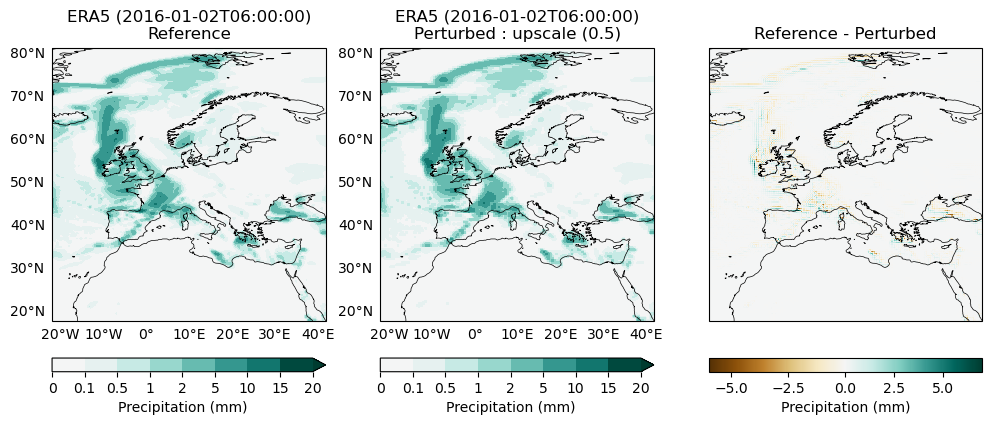

In [59]:
reference_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nReference'
perturbed_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nPerturbed : upscale ({scale_factor})'
cbar_label = 'Precipitation (mm)'
reference_coords = (reference.longitude, reference.latitude)
perturbed_coords = (reference.longitude, reference.latitude)
plot_perturbation(reference=reference.values, perturbed=upscale_case_1, reference_coords=reference_coords, perturbed_coords=perturbed_coords, reference_label=reference_label, perturbed_label=perturbed_label, cbar_label=cbar_label)

### Case 2 : scale factor 0.3

In [60]:
scale_factor = 0.3
resized = cv2.resize(reference.values, (int(patch_size * scale_factor), int(patch_size * scale_factor)), interpolation=cv2.INTER_NEAREST)
upscale_case_2 = cv2.resize(resized, (patch_size, patch_size), interpolation=cv2.INTER_NEAREST)
params = {'scale_factor' : scale_factor}
spatial_perturbations.update({'upscale_case_2' : {'perturbation_params' : params, 'values' : upscale_case_2}})

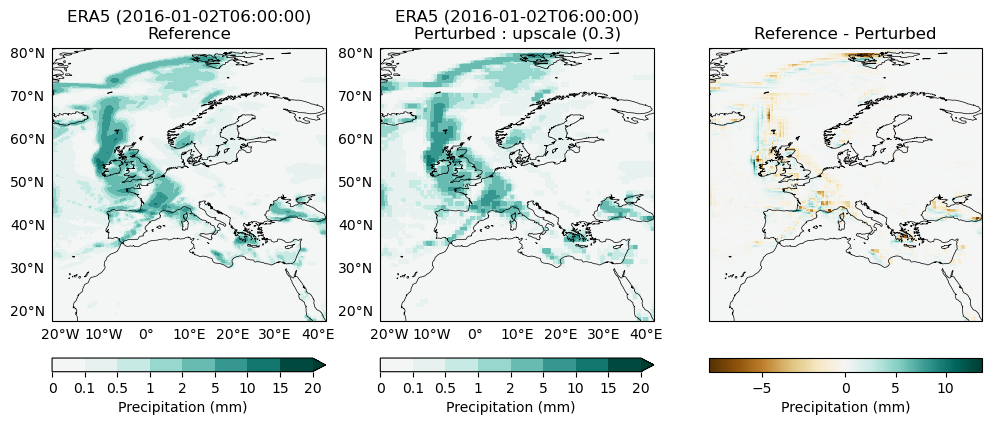

In [61]:
reference_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nReference'
perturbed_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nPerturbed : upscale ({scale_factor})'
cbar_label = 'Precipitation (mm)'
reference_coords = (reference.longitude, reference.latitude)
perturbed_coords = (reference.longitude, reference.latitude)
plot_perturbation(reference=reference.values, perturbed=upscale_case_2, reference_coords=reference_coords, perturbed_coords=perturbed_coords, reference_label=reference_label, perturbed_label=perturbed_label, cbar_label=cbar_label)

### Case 3 : scale factor 0.1

In [62]:
scale_factor = 0.1
resized = cv2.resize(reference.values, (int(patch_size * scale_factor), int(patch_size * scale_factor)), interpolation=cv2.INTER_NEAREST)
upscale_case_3 = cv2.resize(resized, (patch_size, patch_size), interpolation=cv2.INTER_NEAREST)
params = {'scale_factor' : scale_factor}
spatial_perturbations.update({'upscale_case_3' : {'perturbation_params' : params, 'values' : upscale_case_3}})

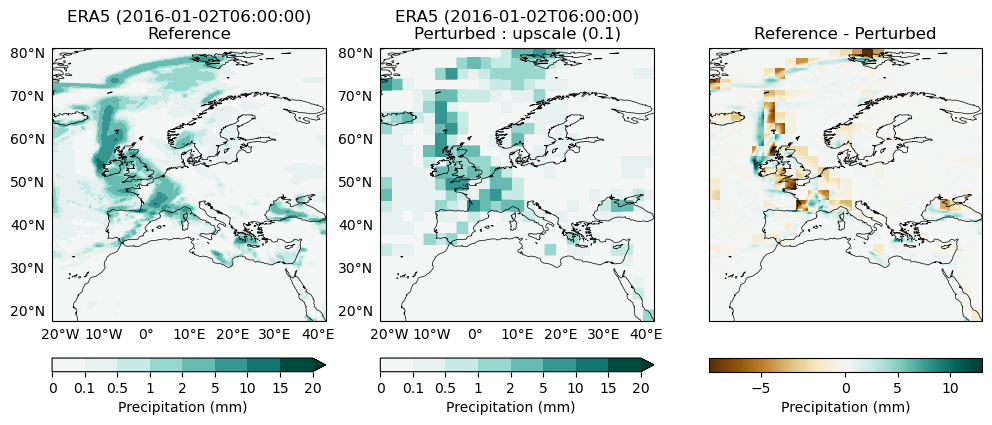

In [63]:
reference_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nReference'
perturbed_label = f'ERA5 ({ref_day_reanalysis[:-7]})\nPerturbed : upscale ({scale_factor})'
cbar_label = 'Precipitation (mm)'
reference_coords = (reference.longitude, reference.latitude)
perturbed_coords = (reference.longitude, reference.latitude)
plot_perturbation(reference=reference.values, perturbed=upscale_case_3, reference_coords=reference_coords, perturbed_coords=perturbed_coords, reference_label=reference_label, perturbed_label=perturbed_label, cbar_label=cbar_label)

# Perturbation #4 : noise on different scales